### ACT data

Abg-CoQA structure

* Story: background paragraph (facts, entities)
* Conversation: history turns (Q₁→A₁, …, Qₖ→Aₖ)
* Target question: current user query

Ambiguity

* Non-ambiguous → answer directly
* Ambiguous → question is unclear

If ambiguous

* Ask clarifying question q
* User replies aᵢ
* Final answer yᵢ depends on aᵢ

In [ ]:
import json
from collections import Counter
import numpy as np

paths = {
    "coqa train": "data/coqa_abg_train_converted.jsonl",
    "coqa val": "data/coqa_abg_val_converted.jsonl",
}

def load(path):
    with open(path) as f:
        return [json.loads(l) for l in f]

datasets = {k: load(v) for k, v in paths.items()}

for name, data in datasets.items():
    print(f"{name}: {len(data)} samples")

coqa train: 741 samples
coqa val: 130 samples


In [ ]:
import json
import numpy as np
import pandas as pd
from transformers import AutoTokenizer

DATA_PATH = "data/coqa_abg_val_converted.jsonl"
MODEL_NAME = "Qwen/Qwen2.5-1.5B"
TEXT_FIELD = None
MODE = "gen_clarify_q"
SHOW_LONGEST = 5

QA_INPUT = 'Question:'
QA_OUTPUT = 'Answer:'
CLARIFY_Q = 'Clarifying Question:'
CLARIFY_A = 'Clarifying Answer:'

def gen_clarify_q_prompt(qa_input, clarify_q=None):
    lines = []
    lines.append(f"{QA_INPUT} {qa_input.strip()}")
    if clarify_q:
        lines.append(f"{CLARIFY_Q} {clarify_q.strip()}")
        lines.append("")
    else:
        lines.append(f"{CLARIFY_Q}")
    return "\n".join(lines)

def gen_clarify_a_prompt(qa_input, clarify_q, qa_output, clarify_a=None):
    lines = []
    lines.append(f"{QA_INPUT} {qa_input.strip()}")
    lines.append(f"{CLARIFY_Q} {clarify_q.strip()}")
    lines.append(f"{QA_OUTPUT} {qa_output.strip()}")
    if clarify_a:
        lines.append(f"{CLARIFY_A} {clarify_a.strip()}")
        lines.append("")
    else:
        lines.append(f"{CLARIFY_A}")
    return "\n".join(lines)

def gen_direct_qa_output_prompt(qa_input, qa_output=None):
    lines = []
    lines.append(f"{QA_INPUT} {qa_input.strip()}")
    if qa_output:
        lines.append(f"{QA_OUTPUT} {qa_output.strip()}")
        lines.append("")
    else:
        lines.append(f"{QA_OUTPUT}")
    return "\n".join(lines)

def gen_qa_output_prompt(qa_input, clarify_q, clarify_a, qa_output=None):
    lines = []
    lines.append(f"{QA_INPUT} {qa_input.strip()}")
    lines.append(f"{CLARIFY_Q} {clarify_q.strip()}")
    lines.append(f"{CLARIFY_A} {clarify_a.strip()}")
    if qa_output:
        lines.append(f"{QA_OUTPUT} {qa_output.strip()}")
        lines.append("")
    else:
        lines.append(f"{QA_OUTPUT}")
    return "\n".join(lines)


def preprocess_like_training(ex, mode):
    sft_examples = []
    if mode == 'gen_clarify_q':
        sft_examples.append(
            gen_clarify_q_prompt(
                qa_input=ex['question'],
                clarify_q=ex['clarification']['question'],
            )
        )
    elif mode == 'gen_clarify_a':
        for answer in ex['clarification']['answers']:
            sft_examples.append(
                gen_clarify_a_prompt(
                    qa_input=ex['question'],
                    clarify_q=ex['clarification']['question'],
                    qa_output=answer['response'],
                    clarify_a=answer['answer'],
                )
            )
    elif mode == 'gen_qa_output':
        for answer in ex['clarification']['answers']:
            sft_examples.append(
                gen_qa_output_prompt(
                    qa_input=ex['question'],
                    clarify_q=ex['clarification']['question'],
                    clarify_a=answer['answer'],
                    qa_output=answer['response'],
                )
            )
    elif mode == 'gen_direct_qa_output':
        for answer in ex['clarification']['answers']:
            sft_examples.append(
                gen_direct_qa_output_prompt(
                    qa_input=ex['question'],
                    qa_output=answer['response'],
                )
            )
    else:
        raise ValueError(f"Unknown mode: {mode}")
    return sft_examples


with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw_examples = [json.loads(line) for line in f]

print(f"Loaded raw examples: {len(raw_examples)}")

texts = []
meta = []

for ex in raw_examples:
    built = preprocess_like_training(ex, MODE)
    for i, txt in enumerate(built):
        texts.append(txt)
        meta.append({
            "id": ex.get("id"),
            "raw_question_len_chars": len(ex.get("question", "")),
            "n_clarification_answers": len(ex.get("clarification", {}).get("answers", [])),
            "variant_index": i,
        })

print(f"Built training texts for mode={MODE}: {len(texts)}")

# tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# compute stats
rows = []
for txt, m in zip(texts, meta):
    enc = tokenizer(txt, add_special_tokens=True, truncation=False)
    token_len = len(enc["input_ids"])
    rows.append({
        **m,
        "char_len": len(txt),
        "word_len": len(txt.split()),
        "token_len": token_len,
        "text": txt,
    })

df = pd.DataFrame(rows)

print("\n=== BASIC COUNTS ===")
print(df[["char_len", "word_len", "token_len"]].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

for cutoff in [256, 512, 768, 1024, 1536, 2048]:
    n = (df["token_len"] > cutoff).sum()
    pct = 100 * n / len(df)
    print(f"Over {cutoff:>4} tokens: {n:>4} / {len(df)} ({pct:.1f}%)")

print("\n=== TOKEN LENGTH PERCENTILES ===")
for p in [50, 75, 90, 95, 99, 100]:
    print(f"p{p:>2}: {np.percentile(df['token_len'], p):.1f}")

print("\n=== LONGEST EXAMPLES ===")
longest = df.sort_values("token_len", ascending=False).head(SHOW_LONGEST)
display(longest[["id", "variant_index", "char_len", "word_len", "token_len"]])

for idx, row in longest.iterrows():
    print("\n" + "="*100)
    print(f"id: {row['id']} | variant_index: {row['variant_index']} | token_len: {row['token_len']}")
    print("-"*100)
    print(row["text"][:3000])  # preview only


# optional: save stats
OUT_CSV = "/content/length_eda.csv"
df.drop(columns=["text"]).to_csv(OUT_CSV, index=False)
print(f"\nSaved per-example stats to: {OUT_CSV}")

Loaded raw examples: 130
Built training texts for mode=gen_clarify_q: 130

=== BASIC COUNTS ===
          char_len    word_len   token_len
count   130.000000  130.000000  130.000000
mean   1805.453846  310.946154  411.646154
std     485.005428   79.865033  110.359515
min     923.000000  168.000000  210.000000
50%    1776.000000  297.000000  402.500000
75%    1988.000000  344.750000  450.750000
90%    2325.900000  404.100000  537.400000
95%    2433.550000  414.550000  578.800000
99%    3799.710000  641.000000  875.650000
max    4056.000000  686.000000  881.000000
Over  256 tokens:  124 / 130 (95.4%)
Over  512 tokens:   16 / 130 (12.3%)
Over  768 tokens:    3 / 130 (2.3%)
Over 1024 tokens:    0 / 130 (0.0%)
Over 1536 tokens:    0 / 130 (0.0%)
Over 2048 tokens:    0 / 130 (0.0%)

=== TOKEN LENGTH PERCENTILES ===
p50: 402.5
p75: 450.8
p90: 537.4
p95: 578.8
p99: 875.6
p100: 881.0

=== LONGEST EXAMPLES ===


,id,variant_index,char_len,word_len,token_len
2,3c8hj7uop7uralfzrju9tmfh6z1zmd|7|2,0,3800,641,881
3,3c8hj7uop7uralfzrju9tmfh6z1zmd|20|2,0,3799,641,880
33,3y5140z9dxgb0yn2jvyfav6mfrupim|17|2,0,4056,686,865
14,3ve8ayvf8mx6kfmvw6qjlcy4aqc8f6|14|2,0,2462,425,615
13,3ve8ayvf8mx6kfmvw6qjlcy4aqc8f6|7|2,0,2400,414,600



id: 3c8hj7uop7uralfzrju9tmfh6z1zmd|7|2 | variant_index: 0 | token_len: 881
----------------------------------------------------------------------------------------------------
Question: Story:
The following are selected contributors' notes for an essay collection. KATY BUTLER, a 2004 finalist for a National Magazine Award, has written for The New Yorker, the New York Times, Mother Jones, Salon, Tricycle, and other magazines. She was born in South Africa and raised in England, and came to the United States with her family at the age of eight. "Everything Is Holy," her essay about nature worship, Buddhism , and ecology, was selected for Best Buddhist Writing 2006. In 2009 she won a literary award from the Elizabeth George Foundation. "What Broke My Father's Heart" was named a "notable narrative" by the Nieman Foundation for Journalism at Harvard, won a first-place award from the Association of Health Care Journalists, and was named one of the 100 Best Magazine Articles of All Time. Butl

### Clarifying question generation SFT with Qwen2.5-1.5B

In [ ]:
!python src/sft.py \
  --model Qwen/Qwen2.5-1.5B \
  --experiment_name qwen_1.5b_test_coqaabg \
  --train_paths data/coqa_abg_train.jsonl \
  --dev_paths data/coqa_abg_val.jsonl \
  --mode gen_clarify_q \
  --output_dir /content/drive/MyDrive/clarifying_q_runs \
  --epochs 3 \
  --learning_rate 2e-4 \
  --batch_size 1 \
  --grad_accum_steps 8

2026-04-07 07:08:31.445219: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775545711.466869   10675 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775545711.473733   10675 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775545711.491683   10675 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775545711.491728   10675 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775545711.491732   10675 computation_placer.cc:177] computation placer alr

In [ ]:
!python src/inference.py \
  --model Qwen/Qwen2.5-1.5B \
  --checkpoint /content/drive/MyDrive/clarifying_q_runs/Qwen_Qwen2.5-1.5B/Qwen/Qwen2.5-1.5B/gen_clarify_q/qwen_1.5b_test_coqaabg \
  --adapter best_checkpoint \
  --dataset_path data/coqa_abg_val.jsonl \
  --mode clarify_q \
  --batch_size 1 \
  --n_samples 1 \
  --temperature 0.7 \
  --max_length 96

2026-04-07 10:19:51.801979: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775557191.822552   23039 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775557191.830340   23039 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775557191.849484   23039 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775557191.849508   23039 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775557191.849511   23039 computation_placer.cc:177] computation placer alr

### Metrics and plots

In [1]:
!pip install rouge-score nltk

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=2092673ae6430d4f4742b8416ec5c79ed360583c3a3eacb8b9e68d2cdf3f3a50
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [2]:
!python metrics.py \
  --input_path coqa_abg_val.clarify_q_s1.jsonl \
  --mode clarify_q

Clarifying Question Quality (all):
bleu	rouge_l
0.020	0.123

Clarifying Question Quality (ambiguous only):
bleu	rouge_l
0.020	0.123

Metrics saved to coqa_abg_val.clarify_q_s1.metrics.json


In [13]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

LOG_JSON_PATH = "log_history.json"

with open(LOG_JSON_PATH, "r", encoding="utf-8") as f:
    log_history = json.load(f)

df = pd.DataFrame(log_history)

eval_loss_col = "eval_coqa_abg_val.jsonl_loss"
eval_runtime_col = "eval_coqa_abg_val.jsonl_runtime"
eval_sps_col = "eval_coqa_abg_val.jsonl_samples_per_second"
eval_stepsps_col = "eval_coqa_abg_val.jsonl_steps_per_second"

train_df = df[df["loss"].notna()].copy()
eval_df = df[df[eval_runtime_col].notna()].copy()
summary_df = df[df["train_runtime"].notna()].copy()

print("Train rows:", len(train_df))
print("Eval rows:", len(eval_df))
print("Summary rows:", len(summary_df))
print("Non-NaN eval loss rows:", df[eval_loss_col].notna().sum() if eval_loss_col in df.columns else 0)

Train rows: 27
Eval rows: 3
Summary rows: 1
Non-NaN eval loss rows: 0


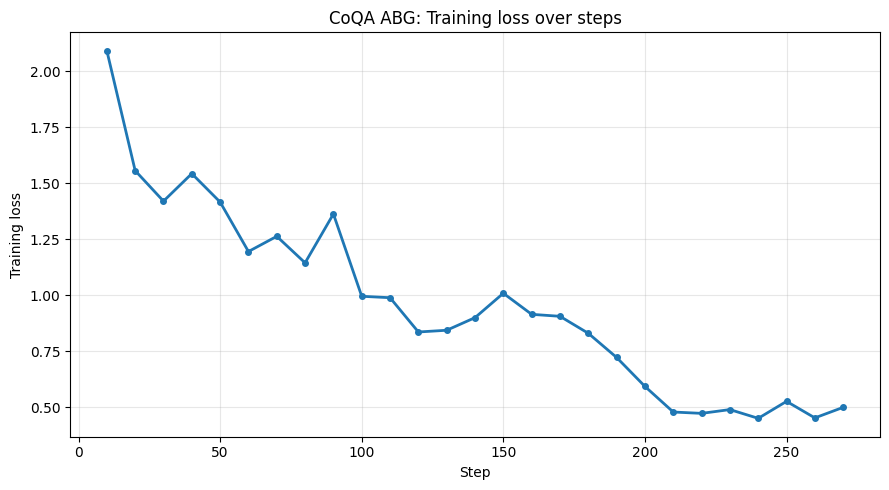

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(train_df["step"], train_df["loss"], marker="o", linewidth=2, markersize=4)
plt.xlabel("Step")
plt.ylabel("Training loss")
plt.title("CoQA ABG: Training loss over steps")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
eval_metrics_table = eval_df[
    ["epoch", "step", eval_runtime_col, eval_sps_col, eval_stepsps_col]
].copy()

eval_metrics_table.columns = [
    "epoch",
    "step",
    "eval_runtime_sec",
    "eval_samples_per_sec",
    "eval_steps_per_sec",
]

display(eval_metrics_table)

,epoch,step,eval_runtime_sec,eval_samples_per_sec,eval_steps_per_sec
9,0.993252,92,27.5139,4.725,4.725
19,1.997301,185,27.7735,4.681,4.681
29,2.979757,276,28.3808,4.581,4.581


In [16]:
final_summary = summary_df.iloc[-1][[
    "train_runtime",
    "train_samples_per_second",
    "train_steps_per_second",
    "train_loss",
    "epoch",
    "step"
]].to_dict()

final_summary_table = pd.DataFrame({
    "Metric": [
        "Training runtime (sec)",
        "Training runtime (min)",
        "Train samples/sec",
        "Train steps/sec",
        "Final average train loss",
        "Final epoch",
        "Final step"
    ],
    "Value": [
        round(final_summary["train_runtime"], 3),
        round(final_summary["train_runtime"] / 60, 3),
        round(final_summary["train_samples_per_second"], 3),
        round(final_summary["train_steps_per_second"], 3),
        round(final_summary["train_loss"], 6),
        round(final_summary["epoch"], 6),
        int(final_summary["step"]),
    ]
})

display(final_summary_table)

,Metric,Value
0,Training runtime (sec),1550.924000
1,Training runtime (min),25.849000
2,Train samples/sec,1.433000
3,Train steps/sec,0.178000
4,Final average train loss,0.947422
5,Final epoch,2.979757
6,Final step,276.000000
